<a href="https://colab.research.google.com/github/Zainab-Binte-Khalid/urdu-ocr-codesaviours-si26-zainab/blob/main/Copy_of_Copy_of_SI26_Week04_Zainab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive"):
    if "Urdu_OCR" in dirs:
        print(os.path.join(root, "Urdu_OCR"))

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks']


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Urdu_OCR"))

False


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Urdu_OCR']


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/Urdu_OCR"))

True


In [ ]:
import os

checkpoint = "/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_9"
print(os.path.exists(checkpoint))
print(os.listdir(checkpoint))

True
['model.safetensors', 'preprocessor_config.json', 'tokenizer_config.json', 'special_tokens_map.json', 'config.json', 'generation_config.json', 'vocab.json', 'merges.txt', 'tokenizer.json']


In [ ]:
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

checkpoint = "/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_9"

model = VisionEncoderDecoderModel.from_pretrained(checkpoint).to(device)
processor = TrOCRProcessor.from_pretrained(checkpoint)

print("✅ Epoch 9 loaded successfully")

Using: cuda


Loading weights:   0%|          | 0/480 [00:01<?, ?it/s]

✅ Epoch 9 loaded successfully


In [ ]:
save_path = "/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_10"
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_10/processor_config.json']

In [ ]:
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = "/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_10"

model = VisionEncoderDecoderModel.from_pretrained(checkpoint).to(device)
processor = TrOCRProcessor.from_pretrained(checkpoint)

print("Epoch 10 loaded successfully")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Epoch 10 loaded successfully


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_10"))

['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json']


In [ ]:
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.8 MB/s eta 0:00:00


In [ ]:
from jiwer import cer

In [ ]:
import jiwer
print(jiwer)

<module 'jiwer' from '/usr/local/lib/python3.12/dist-packages/jiwer/__init__.py'>


In [ ]:
print("test_loader_final" in globals())

False


In [ ]:
import torch

In [ ]:
print(len(test_loader_final))

NameError: name 'test_loader_final' is not defined

In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image

train_df = pd.read_csv('/content/drive/MyDrive/Urdu_OCR/train_v4_final.csv')
test_df_v4 = pd.read_csv('/content/drive/MyDrive/Urdu_OCR/test_v4_final.csv')

class UrduOCRDatasetFinal(Dataset):
    def __init__(self, df, processor):
        self.data = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image']).convert('RGB')
        encoding = self.processor(image, return_tensors='pt')
        pixel_values = encoding.pixel_values.squeeze()
        labels = self.processor.tokenizer(
            row['text'],
            padding='max_length',
            max_length=128,
            truncation=True
        ).input_ids
        labels = torch.tensor(labels)
        return {
            'pixel_values': pixel_values,
            'labels': labels,
            'source': row['source']
        }

train_dataset_final = UrduOCRDatasetFinal(train_df, processor)
test_dataset_final = UrduOCRDatasetFinal(test_df_v4, processor)

train_loader_final = DataLoader(train_dataset_final, batch_size=4, shuffle=True)
test_loader_final = DataLoader(test_dataset_final, batch_size=4)

print(f"Training batches: {len(train_loader_final)}")
print(f"Test samples: {len(test_dataset_final)}")

Training batches: 585
Test samples: 585


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Urdu_OCR/images"))
print(os.path.exists("/content/drive/MyDrive/Urdu_OCR/data"))

False
True


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Urdu_OCR/images"):
    if "scene_word_0460.jpg" in files:
        print(os.path.join(root, "scene_word_0460.jpg"))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers==4.41.2 torch pillow pandas sentencepiece jiwer -q

from transformers import VisionEncoderDecoderModel, TrOCRProcessor
import torch, os, re
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Resume from epoch 9
resume_path = '/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_9'
model = VisionEncoderDecoderModel.from_pretrained(resume_path).to(device)
processor = TrOCRProcessor.from_pretrained(resume_path)
print('Resumed from epoch 9')

# Rebuild data
train_df = pd.read_csv('/content/drive/MyDrive/Urdu_OCR/train_v4_final.csv')
test_df_v4 = pd.read_csv('/content/drive/MyDrive/Urdu_OCR/test_v4_final.csv')

class UrduOCRDatasetFinal(Dataset):
    def __init__(self, df, processor, processed_root):
        self.data = df.reset_index(drop=True)
        self.processor = processor
        self.processed_root = processed_root
        self.exact_lookup, self.fuzzy_lookup = {}, {}
        for category in os.listdir(processed_root):
            cat_path = os.path.join(processed_root, category)
            if os.path.isdir(cat_path):
                for fname in os.listdir(cat_path):
                    full_path = os.path.join(cat_path, fname)
                    self.exact_lookup[fname] = full_path
                    m = re.match(r'([a-zA-Z_]+?)_?(\d+)(\.\w+)$', fname)
                    if m:
                        self.fuzzy_lookup.setdefault((m.group(1).rstrip('_'), int(m.group(2))), full_path)

    def __len__(self):
        return len(self.data)

    def _resolve_path(self, image_field):
        if os.path.isabs(image_field) and os.path.exists(image_field):
            return image_field
        basename = os.path.basename(image_field)
        if basename in self.exact_lookup:
            return self.exact_lookup[basename]
        m = re.search(r'(\d+)', basename)
        if m:
            num = int(m.group(1))
            for (prefix, known_num), path in self.fuzzy_lookup.items():
                if known_num == num:
                    return path
        return None

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = self._resolve_path(row['image'])
        if image_path is None:
            raise FileNotFoundError(f"Could not resolve: {row['image']}")
        image = Image.open(image_path).convert('RGB')
        pixel_values = self.processor(image, return_tensors='pt').pixel_values.squeeze()
        labels = self.processor.tokenizer(row['text'], padding='max_length', max_length=128, truncation=True).input_ids
        return {'pixel_values': pixel_values, 'labels': torch.tensor(labels), 'source': row['source']}

processed_root = '/content/drive/MyDrive/Urdu_OCR/data/processed'
train_dataset_final = UrduOCRDatasetFinal(train_df, processor, processed_root)
test_dataset_final = UrduOCRDatasetFinal(test_df_v4, processor, processed_root)

train_loader_final = DataLoader(train_dataset_final, batch_size=4, shuffle=True)
test_loader_final = DataLoader(test_dataset_final, batch_size=4)
print('Batches:', len(train_loader_final), '| Test:', len(test_dataset_final))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 49.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Resumed from epoch 9
Batches: 585 | Test: 585


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = AdamW(model.parameters(), lr=3e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=10)
for _ in range(9):          # fast-forward scheduler to match epoch 9 already done
    scheduler.step()

checkpoint_dir = '/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final'

model.train()
total_loss = 0
print(f'Epoch 10/10 | LR: {scheduler.get_last_lr()[0]:.2e}')
for batch_idx, batch in enumerate(train_loader_final):
    pixel_values = batch['pixel_values'].to(device)
    labels = batch['labels'].to(device)
    outputs = model(pixel_values=pixel_values, labels=labels)
    loss = outputs.loss
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    total_loss += loss.item()
    if batch_idx % 100 == 0:
        print(f'  Batch {batch_idx}/{len(train_loader_final)} | Loss: {loss.item():.4f}')

scheduler.step()
print(f'Epoch 10 complete | Avg Loss: {total_loss/len(train_loader_final):.4f}')

epoch_save_path = f'{checkpoint_dir}/epoch_10'
model.save_pretrained(epoch_save_path)
processor.save_pretrained(epoch_save_path)
print('Saved:', epoch_save_path)

/tmp/ipykernel_713/2868805870.py:7: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 10/10 | LR: 7.34e-07
  Batch 0/585 | Loss: 0.0024
  Batch 100/585 | Loss: 0.0068
  Batch 200/585 | Loss: 0.0060
  Batch 300/585 | Loss: 0.0020
  Batch 400/585 | Loss: 0.0026
  Batch 500/585 | Loss: 0.0137
Epoch 10 complete | Avg Loss: 0.0551


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_10


In [ ]:
from jiwer import cer
from collections import defaultdict

model.eval()
all_predictions, all_actuals, all_sources = [], [], []

with torch.no_grad():
    for batch in test_loader_final:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels']
        sources = batch['source']
        generated_ids = model.generate(pixel_values, max_new_tokens=128)
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
        actual_text = processor.batch_decode(labels, skip_special_tokens=True)
        for pred, actual, src in zip(generated_text, actual_text, sources):
            all_predictions.append(pred.strip())
            all_actuals.append(actual.strip())
            all_sources.append(src)

correct = sum(1 for p, a in zip(all_predictions, all_actuals) if p == a)
total = len(all_actuals)
print(f'=== FINAL RESULTS (epoch 10) ===')
print(f'Exact-match: {(correct/total)*100:.1f}% ({correct}/{total})')
print(f'CER: {cer(all_actuals, all_predictions)*100:.1f}%')

cat_preds, cat_actuals = defaultdict(list), defaultdict(list)
for pred, actual, src in zip(all_predictions, all_actuals, all_sources):
    cat_preds[src].append(pred)
    cat_actuals[src].append(actual)

print('\n=== Per-category ===')
for cat in cat_preds:
    n = len(cat_preds[cat])
    cat_correct = sum(1 for p, a in zip(cat_preds[cat], cat_actuals[cat]) if p == a)
    print(f'{cat}: {(cat_correct/n)*100:.1f}% exact, {cer(cat_actuals[cat], cat_preds[cat])*100:.1f}% CER ({n} samples)')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


=== FINAL RESULTS (epoch 10) ===
Exact-match: 24.3% (142/585)
CER: 16.4%

=== Per-category ===
natural_scene_dataset: 49.5% exact, 20.5% CER (200 samples)
clean_printed_dataset: 10.3% exact, 9.5% CER (300 samples)
handwritten: 19.6% exact, 23.6% CER (56 samples)
newspaper: 0.0% exact, 76.1% CER (8 samples)
synthetic: 7.1% exact, 52.2% CER (14 samples)
signboard: 0.0% exact, 160.4% CER (7 samples)


In [ ]:
final_path = '/content/drive/MyDrive/Urdu_OCR/SI26-urdu-ocr-model-final'

model.save_pretrained(final_path)
processor.save_pretrained(final_path)
print(f'Saved to: {final_path}')

import os
print('Contents:', os.listdir(final_path))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/Urdu_OCR/SI26-urdu-ocr-model-final
Contents: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json']


In [ ]:
import json

results = {
    'epoch': 10,
    'exact_match_overall': 24.3,
    'cer_overall': 16.4,
    'per_category': {
        'natural_scene_dataset': {'exact_match': 49.5, 'cer': 20.5, 'n': 200},
        'clean_printed_dataset': {'exact_match': 10.3, 'cer': 9.5, 'n': 300},
        'handwritten': {'exact_match': 19.6, 'cer': 23.6, 'n': 56},
        'newspaper': {'exact_match': 0.0, 'cer': 76.1, 'n': 8},
        'synthetic': {'exact_match': 7.1, 'cer': 52.2, 'n': 14},
        'signboard': {'exact_match': 0.0, 'cer': 160.4, 'n': 7},
    }
}

with open(f'{final_path}/eval_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved eval_results.json')

Saved eval_results.json


In [ ]:
import os
final_path = '/content/drive/MyDrive/Urdu_OCR/SI26-urdu-ocr-model-final'
if os.path.exists(final_path):
    print('✅ Found:', os.listdir(final_path))
else:
    print('❌ Not found — you need to run the save_pretrained cell')

✅ Found: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json', 'eval_results.json']


In [ ]:
from jiwer import cer
from collections import defaultdict
import json

results_path = '/content/drive/MyDrive/Urdu_OCR/all_epochs_eval.json'

# resume from existing results if this gets interrupted and rerun
try:
    with open(results_path) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}

def evaluate_checkpoint(epoch_num):
    path = f'/content/drive/MyDrive/Urdu_OCR/checkpoints_v5_final/epoch_{epoch_num}'
    m = VisionEncoderDecoderModel.from_pretrained(path).to(device)
    p = TrOCRProcessor.from_pretrained(path)
    m.eval()

    preds, actuals, sources = [], [], []
    with torch.no_grad():
        for batch in test_loader_final:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels']
            src = batch['source']
            generated_ids = m.generate(pixel_values, max_new_tokens=128)
            preds.extend(p.batch_decode(generated_ids, skip_special_tokens=True))
            actuals.extend(p.batch_decode(labels, skip_special_tokens=True))
            sources.extend(src)

    preds = [x.strip() for x in preds]
    actuals = [x.strip() for x in actuals]
    correct = sum(1 for x, y in zip(preds, actuals) if x == y)
    exact = (correct / len(actuals)) * 100
    c = cer(actuals, preds) * 100

    cat_preds, cat_actuals = defaultdict(list), defaultdict(list)
    for pr, ac, sr in zip(preds, actuals, sources):
        cat_preds[sr].append(pr)
        cat_actuals[sr].append(ac)
    per_cat = {}
    for cat in cat_preds:
        n = len(cat_preds[cat])
        cc = sum(1 for x, y in zip(cat_preds[cat], cat_actuals[cat]) if x == y)
        per_cat[cat] = {'exact_match': (cc/n)*100, 'cer': cer(cat_actuals[cat], cat_preds[cat])*100, 'n': n}

    print(f'Epoch {epoch_num}: {exact:.1f}% exact-match, {c:.1f}% CER')
    return {'exact_match': exact, 'cer': c, 'per_category': per_cat}

for ep in range(1, 11):
    if str(ep) in all_results:
        print(f'Epoch {ep} already done, skipping')
        continue
    all_results[str(ep)] = evaluate_checkpoint(ep)
    with open(results_path, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f'Saved progress through epoch {ep}\n')

print('All epochs evaluated.')

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Epoch 1: 0.9% exact-match, 79.2% CER
Saved progress through epoch 1



Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Epoch 2: 2.4% exact-match, 71.5% CER
Saved progress through epoch 2



Loading weights:   0%|          | 0/480 [00:02<?, ?it/s]

...

Epoch 8: 21.9% exact-match, 18.9% CER
Saved progress through epoch 8



Loading weights:   0%|          | 0/480 [00:02<?, ?it/s]

Epoch 9: 24.1% exact-match, 17.8% CER
Saved progress through epoch 9



Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Epoch 10: 24.3% exact-match, 16.4% CER
Saved progress through epoch 10

All epochs evaluated.


In [ ]:
handout_path = '/content/drive/MyDrive/SI26-urdu-ocr-model'
model.save_pretrained(handout_path)
processor.save_pretrained(handout_path)
print(f'Saved to handout-required path: {handout_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to handout-required path: /content/drive/MyDrive/SI26-urdu-ocr-model


In [ ]:
model.eval()
wrong_examples = []

with torch.no_grad():
    for batch in test_loader_final:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels']
        generated_ids = model.generate(pixel_values, max_new_tokens=128)
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
        actual_text = processor.batch_decode(labels, skip_special_tokens=True)

        for pred, actual in zip(generated_text, actual_text):
            if pred.strip() != actual.strip():
                wrong_examples.append({'predicted': pred.strip(), 'actual': actual.strip()})
                if len(wrong_examples) >= 5:
                    break
        if len(wrong_examples) >= 5:
            break

for i, ex in enumerate(wrong_examples, 1):
    print(f'{i}. Predicted: {ex["predicted"]}')
    print(f'   Actual:    {ex["actual"]}\n')

1. Predicted: ڈکیا بلجیم ”وکیا بلبیم بگا سو فیصد کھٹرول چار
   Actual:    ڈکشیا بلجیم ”ڈکشیا بنک بلجیم“ کا سو فیصد کنٹرول چار

2. Predicted: ہوٹل گی جس بھ گھر میں گیس کی شدید بو
   Actual:    نکلنے لگی جس پر گھر میں گیس کی شدید بو

3. Predicted: ریکارڈ کی گئی۔ پنتہ کو یہاں وفاقی ادارہ شاریات کے
   Actual:    ریکارڈ کی گئی۔ ہفتہ کو یہاں وفاقی ادارہ شماریات کے

4. Predicted: جموں کشمیر کی مکمل خوثتاری اور اس کی وحدت پر
   Actual:    جموں کشمیر کی مکمل خودمختاری اور اس کی وحدت پر

5. Predicted: کی گئیں جوکہ 20107070ء میں 128.28 سے زیادہ ہیں۔
   Actual:    کی گئیں جو کہ 2009/10ء میں 1,128 سے زیادہ ہیں۔



final save all

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
final_path = '/content/drive/MyDrive/Urdu_OCR/SI26-urdu-ocr-model-final'
print('Exists:', os.path.exists(final_path))
print('Contents:', os.listdir(final_path) if os.path.exists(final_path) else 'MISSING')

Exists: True
Contents: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json', 'eval_results.json']


In [ ]:
results_path = '/content/drive/MyDrive/Urdu_OCR/all_epochs_eval.json'
print('Exists:', os.path.exists(results_path))

Exists: True


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

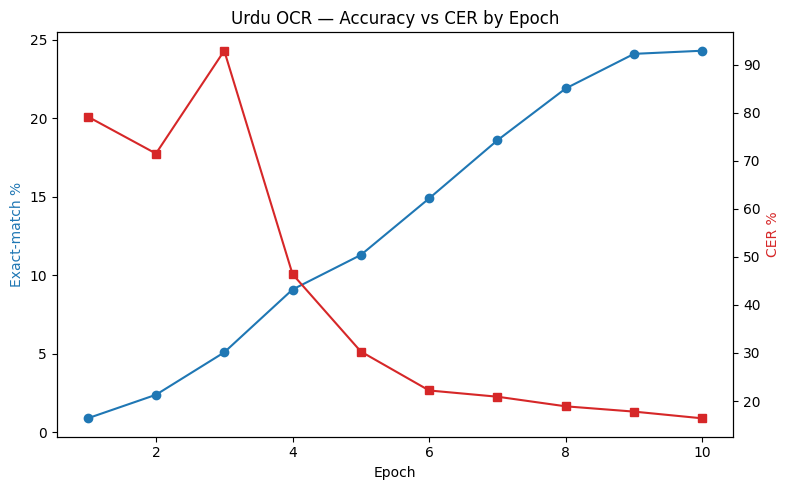

Saved: summary CSVs + trend chart


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/Urdu_OCR/all_epochs_eval.json') as f:
    all_results = json.load(f)

summary_rows = [{'epoch': int(e), 'exact_match': round(r['exact_match'],1), 'cer': round(r['cer'],1)}
                 for e, r in sorted(all_results.items(), key=lambda x: int(x[0]))]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/drive/MyDrive/Urdu_OCR/summary_overall_all_epochs.csv', index=False)

cat_rows = []
for epoch, r in all_results.items():
    for cat, stats in r['per_category'].items():
        cat_rows.append({'epoch': int(epoch), 'category': cat, 'exact_match': round(stats['exact_match'],1),
                          'cer': round(stats['cer'],1), 'n': stats['n']})
cat_df = pd.DataFrame(cat_rows).sort_values(['category','epoch'])
cat_df.to_csv('/content/drive/MyDrive/Urdu_OCR/summary_per_category_all_epochs.csv', index=False)

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(summary_df['epoch'], summary_df['exact_match'], marker='o', color='tab:blue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Exact-match %', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(summary_df['epoch'], summary_df['cer'], marker='s', color='tab:red')
ax2.set_ylabel('CER %', color='tab:red')
plt.title('Urdu OCR — Accuracy vs CER by Epoch')
fig.tight_layout()
plt.savefig('/content/drive/MyDrive/Urdu_OCR/epoch_trend_chart.png', dpi=150)
plt.show()
print('Saved: summary CSVs + trend chart')